# Supplementary Data Figure 4

Environment: env1

In [ ]:
import pandas as pd
import pickle
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import re



import matplotlib as mpl
import sys
sys.path.append("/gpfs/data/shenhavlab/users/ca3261/Visionary_AI/src/analysis/final_figures/final_submission/")
from utils import get_test_roc, get_test_pr, plot_avg_roc_from_dicts, plot_avg_pr_from_dicts, strings_to_na, gest_age_to_days, datetime_to_day_index, add_ethnicity_binaries,proc_smoker, proc_conception, proc_on_yes, proc_on_no, proc_birth_hx, get_ama, get_bmi, proc_db


### plot settings

In [3]:
dpi = 300
font_size = 22
fig_size = 5

### load data

In [8]:
fmf_loo = pd.read_csv("/gpfs/data/shenhavlab/users/ca3261/Visionary_AI/data/fmf_pe_results_cu.csv")
fmf_loo["fmf_prob"] = fmf_loo["pe_before_delivery_percent"] / 100
fmf_loo["id"] = [id.lower() for id in fmf_loo["patient_id"]]
fmf_loo = fmf_loo[["fmf_prob", "id"]]

In [9]:
clinical_unproc = pd.read_csv("/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/clinical_data/clinical_features_all_20250930.csv", index_col=0)
clinical_unproc = clinical_unproc.rename(columns={'Study ID':'id'})

In [10]:
clinical_unproc = clinical_unproc[['id','Maternal hispanic',
       'Maternal Race_Asian', 'Maternal Race_Black',
       'Maternal Race_Multiracial', 'Maternal Race_Other',
       'Maternal Race_Unknown', 'Maternal Race_White']]

In [11]:
clinical = pd.read_csv("/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/clinical_data/clinical_ml_feats_20260430.csv")

### SETTINGS !

In [12]:
# modify here to choose stratification

strat_type='obesity_unlabeled'

all_labels = False

run_obesity = True
run_no_obesity = False
run_chtn = False
run_no_chtn = False

### CU Stablity model

In [13]:
all_mets = pd.read_csv("/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/columbia/rev_strat_pec_hc_pw/run_20260407_stable/meta_probs_auc_0.5/all_pw_metrics.csv")

result = all_mets.loc[all_mets.groupby('pw')['auc'].idxmax(), ['pw', 'hp', 'auc']]


In [14]:
cu_all_probs = []
for pw in range(1, 6):
    hp = result[result["pw"] == pw]["hp"].iloc[0]
    path = f"/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/columbia/rev_strat_pec_hc_pw{pw}/run_20260407_stable/meta_probs_auc_0.5/XGBoost/{hp}_oof.pkl"
    with open(path, "rb") as f:
        data = pickle.load(f)
        cu_all_probs.append(data[1])
cu_all_probs = pd.DataFrame(cu_all_probs)

In [15]:
cu_all_probs = cu_all_probs.T
cu_all_probs["id"] = cu_all_probs.index
cu_all_probs = cu_all_probs.reset_index(drop=True)
cu_all_probs = cu_all_probs.merge(clinical, how="left", on='id')
cu_all_probs = cu_all_probs.merge(fmf_loo, how="left", on='id')
cu_all_probs = cu_all_probs.merge(clinical_unproc, how="left", on='id')

In [16]:
with open("/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/clinical_data/final_pec_20251017.pkl", "rb") as f:
    pec = pickle.load(f)
with open("/gpfs/data/shenhavlab/users/ca3261/Visionary_AI/data/rev_test_pec_cases_20260406.pkl", "rb") as f:
    pec_test = pickle.load(f)
all_pec = pec + pec_test
cu_all_probs["label"] = [int(id in all_pec) for id in cu_all_probs["id"]]

rename_dict = {}

for i in range(6):
    rename_dict[i] = f"pw_{i + 1}"

cu_all_probs = cu_all_probs.rename(columns=rename_dict)

In [17]:
cu_all_probs['avg_prob'] = cu_all_probs[['pw_1', 'pw_2', 'pw_3', 'pw_4', 'pw_5']].mean(axis=1)

In [18]:
model_type='stable'

In [ ]:

if run_obesity:
    cu_all_probs = cu_all_probs[cu_all_probs['Obesity']==1]
if run_no_obesity:
    cu_all_probs = cu_all_probs[cu_all_probs['Obesity']==0]
if run_chtn:
    cu_all_probs = cu_all_probs[cu_all_probs['CHTN']==1]
if run_no_chtn:
    cu_all_probs = cu_all_probs[cu_all_probs['CHTN']==0]

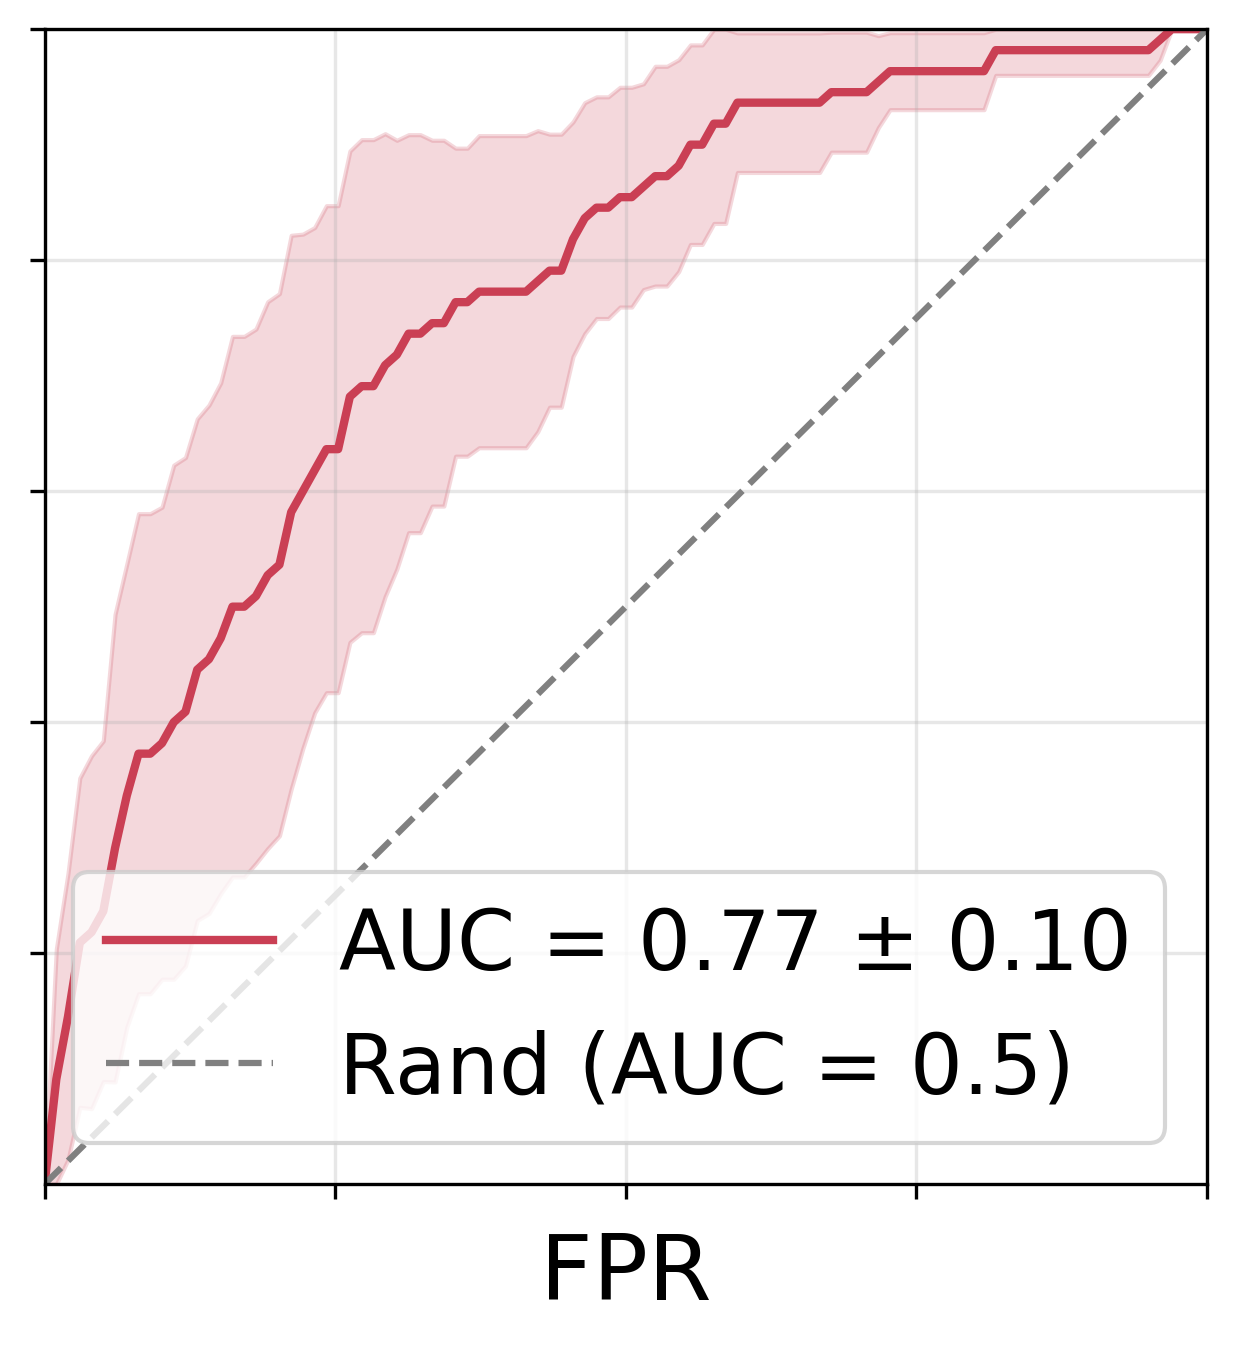

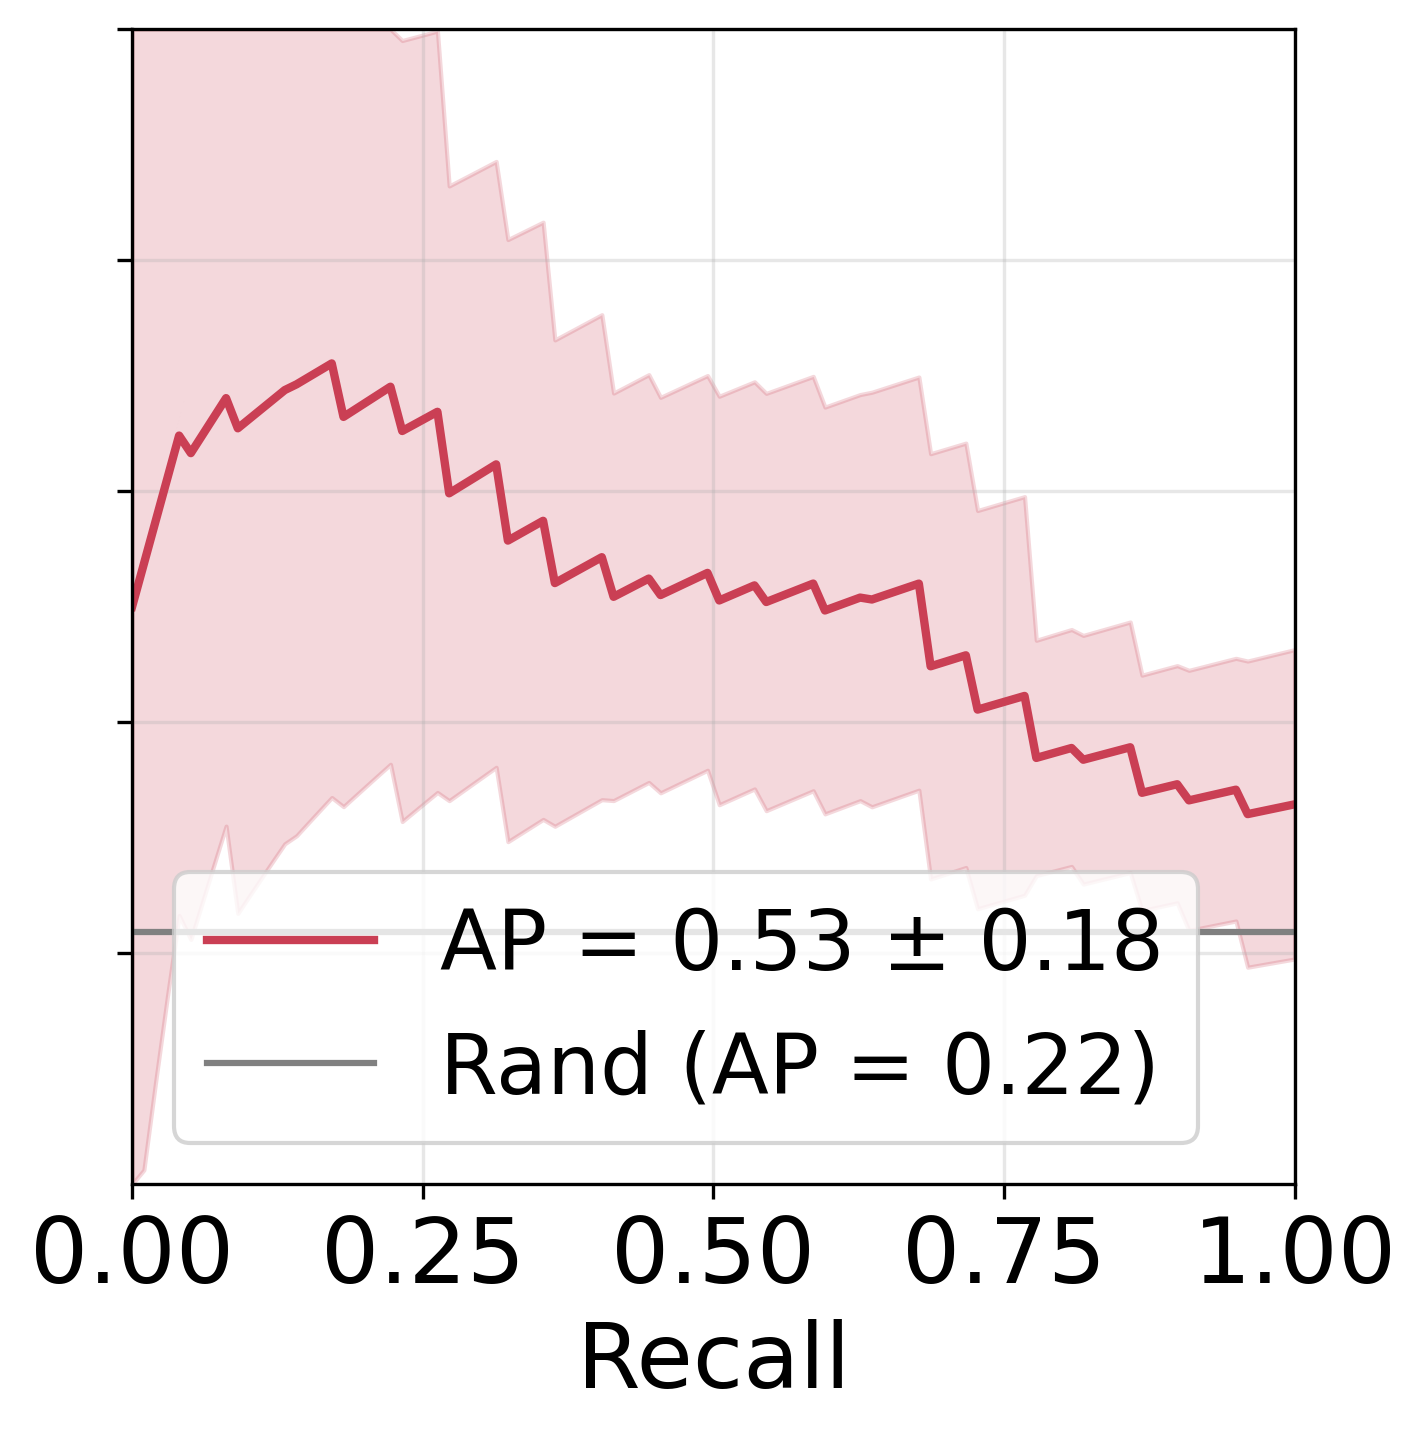

In [ ]:
# ROC
plt.figure(figsize=(fig_size, fig_size), dpi=dpi)
# retinal
reweight = cu_all_probs.copy()
cols = ["Combo"]
reweight["Combo"] = (reweight["Past PEC"] * 0.35 + 0.15 *((reweight["First Preg"]) * (reweight["Age at enrollment"] > 37).astype(int)))
if all_labels:
    plot_avg_roc_from_dicts(reweight, add_col=cols, plot=True, pw=5, color="#CA3F54", rand=True,
                           x_label=True, y_label=True, x_ticks=False, y_ticks=True
                           )
else:
    plot_avg_roc_from_dicts(reweight, add_col=cols, plot=True, pw=5, color="#CA3F54", rand=True,
                       x_label=True, y_label=False, x_ticks=False, y_ticks=False
                       )
plt.title("")
plt.savefig(f'/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/temp_plots/cu_{model_type}_{strat_type}_auc.svg') 
plt.show()

# PR
plt.figure(figsize=(fig_size, fig_size), dpi=dpi)
# retinal
reweight = cu_all_probs.copy()
cols = ["Combo"]
reweight["Combo"] = (reweight["Past PEC"] * 0.35 + 0.15 *((reweight["First Preg"]) * (reweight["Age at enrollment"] > 37).astype(int)))
if all_labels:
    plot_avg_pr_from_dicts(reweight, add_col=cols, plot=True, pw=5, color="#CA3F54", rand=True,
                          )
else:
    plot_avg_pr_from_dicts(reweight, add_col=cols, plot=True, pw=5, color="#CA3F54", rand=True,
                           x_label=True, y_label=False, x_ticks=True, y_ticks=False
                          ),
plt.title("")
plt.savefig(f'/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/temp_plots/cu_{model_type}_{strat_type}_pr.svg') 

plt.show()

### CU Performance model

In [22]:
pw1_5 = "/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/columbia/final_pec_hc_pw1/run_20251020/meta_probs_auc_0.5/XGBoost/{n_estimators_100,max_depth_2,learning_rate_0.3,subsample_1.0,scale_pos_weight_12,n_feats_16}_oof.pkl"
pw2_5 = "/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/columbia/final_pec_hc_pw2/run_20251020/meta_probs_auc_0.5/XGBoost/{n_estimators_100,max_depth_2,learning_rate_0.3,subsample_1.0,scale_pos_weight_12,n_feats_16}_oof.pkl"
pw3_5 = "/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/columbia/final_pec_hc_pw3/run_20251020/meta_probs_auc_0.5/XGBoost/{n_estimators_100,max_depth_3,learning_rate_0.1,subsample_1.0,scale_pos_weight_12,n_feats_16}_oof.pkl"
pw4_5 = "/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/columbia/final_pec_hc_pw4/run_20251020/meta_probs_auc_0.5/XGBoost/{n_estimators_250,max_depth_2,learning_rate_0.3,subsample_1.0,scale_pos_weight_8,n_feats_8}_oof.pkl"
pw5_5 = "/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/columbia/final_pec_hc_pw5/run_20251020/meta_probs_auc_0.5/XGBoost/{n_estimators_250,max_depth_2,learning_rate_0.1,subsample_0.8,scale_pos_weight_12,n_feats_32}_oof.pkl"
pw6_5 = "/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/columbia/final_pec_hc_pw6/run_20251020/meta_probs_auc_0.5/XGBoost/{n_estimators_250,max_depth_2,learning_rate_0.3,subsample_1.0,scale_pos_weight_12,n_feats_8}_oof.pkl"
pw7_5 = "/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/columbia/final_pec_hc_pw7/run_20251020/meta_probs_auc_0.5/XGBoost/{n_estimators_250,max_depth_1,learning_rate_0.1,subsample_0.8,scale_pos_weight_2,n_feats_32}_oof.pkl"
pw8_5 = "/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/columbia/final_pec_hc_pw8/run_20251020/meta_probs_auc_0.5/XGBoost/{n_estimators_250,max_depth_2,learning_rate_0.1,subsample_0.8,scale_pos_weight_2,n_feats_8}_oof.pkl"
pw9_5 = "/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/columbia/final_pec_hc_pw9/run_20251020/meta_probs_auc_0.5/XGBoost/{n_estimators_250,max_depth_2,learning_rate_0.1,subsample_1.0,scale_pos_weight_12,n_feats_32}_oof.pkl"
pw10_5 = "/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/columbia/final_pec_hc_pw10/run_20251020/meta_probs_auc_0.5/XGBoost/{n_estimators_250,max_depth_1,learning_rate_0.3,subsample_1.0,scale_pos_weight_8,n_feats_32}_oof.pkl"


pw_models = [pw1_5,pw2_5,pw3_5,pw4_5,pw5_5,pw6_5,pw7_5,pw8_5,pw9_5,pw10_5]

In [23]:
cu_all_probs = []
for pw in range(0, 10):
    path = pw_models[pw]
    with open(path, "rb") as f:
        data = pickle.load(f)
        cu_all_probs.append(data[1])
cu_all_probs = pd.DataFrame(cu_all_probs)

In [24]:
cu_all_probs = cu_all_probs.T
cu_all_probs["id"] = cu_all_probs.index
cu_all_probs = cu_all_probs.reset_index(drop=True)
cu_all_probs = cu_all_probs.merge(clinical, how="left", on='id')
cu_all_probs = cu_all_probs.merge(fmf_loo, how="left", on='id')
cu_all_probs = cu_all_probs.merge(clinical_unproc, how="left", on='id')

In [25]:
with open("/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/clinical_data/final_pec_20251017.pkl", "rb") as f:
    pec = pickle.load(f)
with open("/gpfs/data/shenhavlab/users/ca3261/Visionary_AI/data/rev_test_pec_cases_20260406.pkl", "rb") as f:
    pec_test = pickle.load(f)
all_pec = pec + pec_test
cu_all_probs["label"] = [int(id in all_pec) for id in cu_all_probs["id"]]

rename_dict = {}

for i in range(10):
    rename_dict[i] = f"pw_{i + 1}"

cu_all_probs = cu_all_probs.rename(columns=rename_dict)

In [26]:
cu_all_probs_o = cu_all_probs.copy()

In [27]:
cu_all_probs = cu_all_probs.merge(clinical_unproc, on='id', how='inner')

In [ ]:
model_type='best'

In [29]:
if run_obesity:
    cu_all_probs = cu_all_probs[cu_all_probs['Obesity']==1]
if run_no_obesity:
    cu_all_probs = cu_all_probs[cu_all_probs['Obesity']==0]
if run_chtn:
    cu_all_probs = cu_all_probs[cu_all_probs['CHTN']==1]
if run_no_chtn:
    cu_all_probs = cu_all_probs[cu_all_probs['CHTN']==0]


In [30]:
cu_all_probs['avg_prob'] = cu_all_probs[['pw_1', 'pw_2', 'pw_3', 'pw_4', 'pw_5',
                                         'pw_6', 'pw_7', 'pw_8', 'pw_9', 'pw_10']].mean(axis=1)

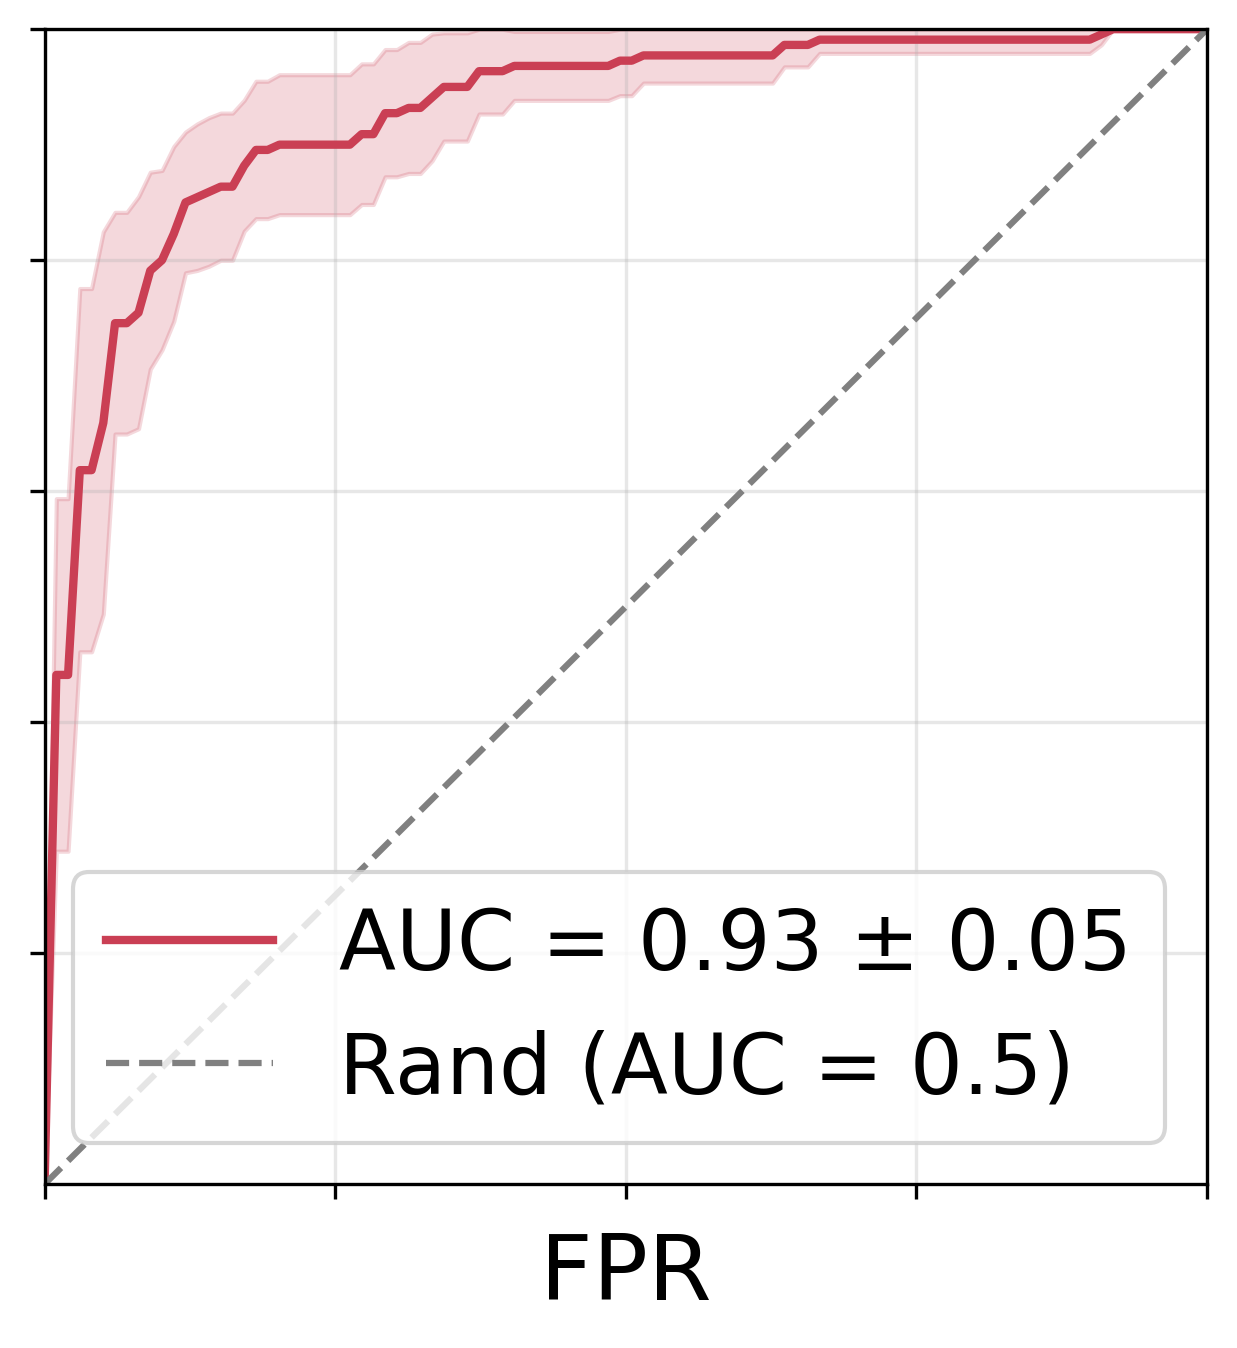

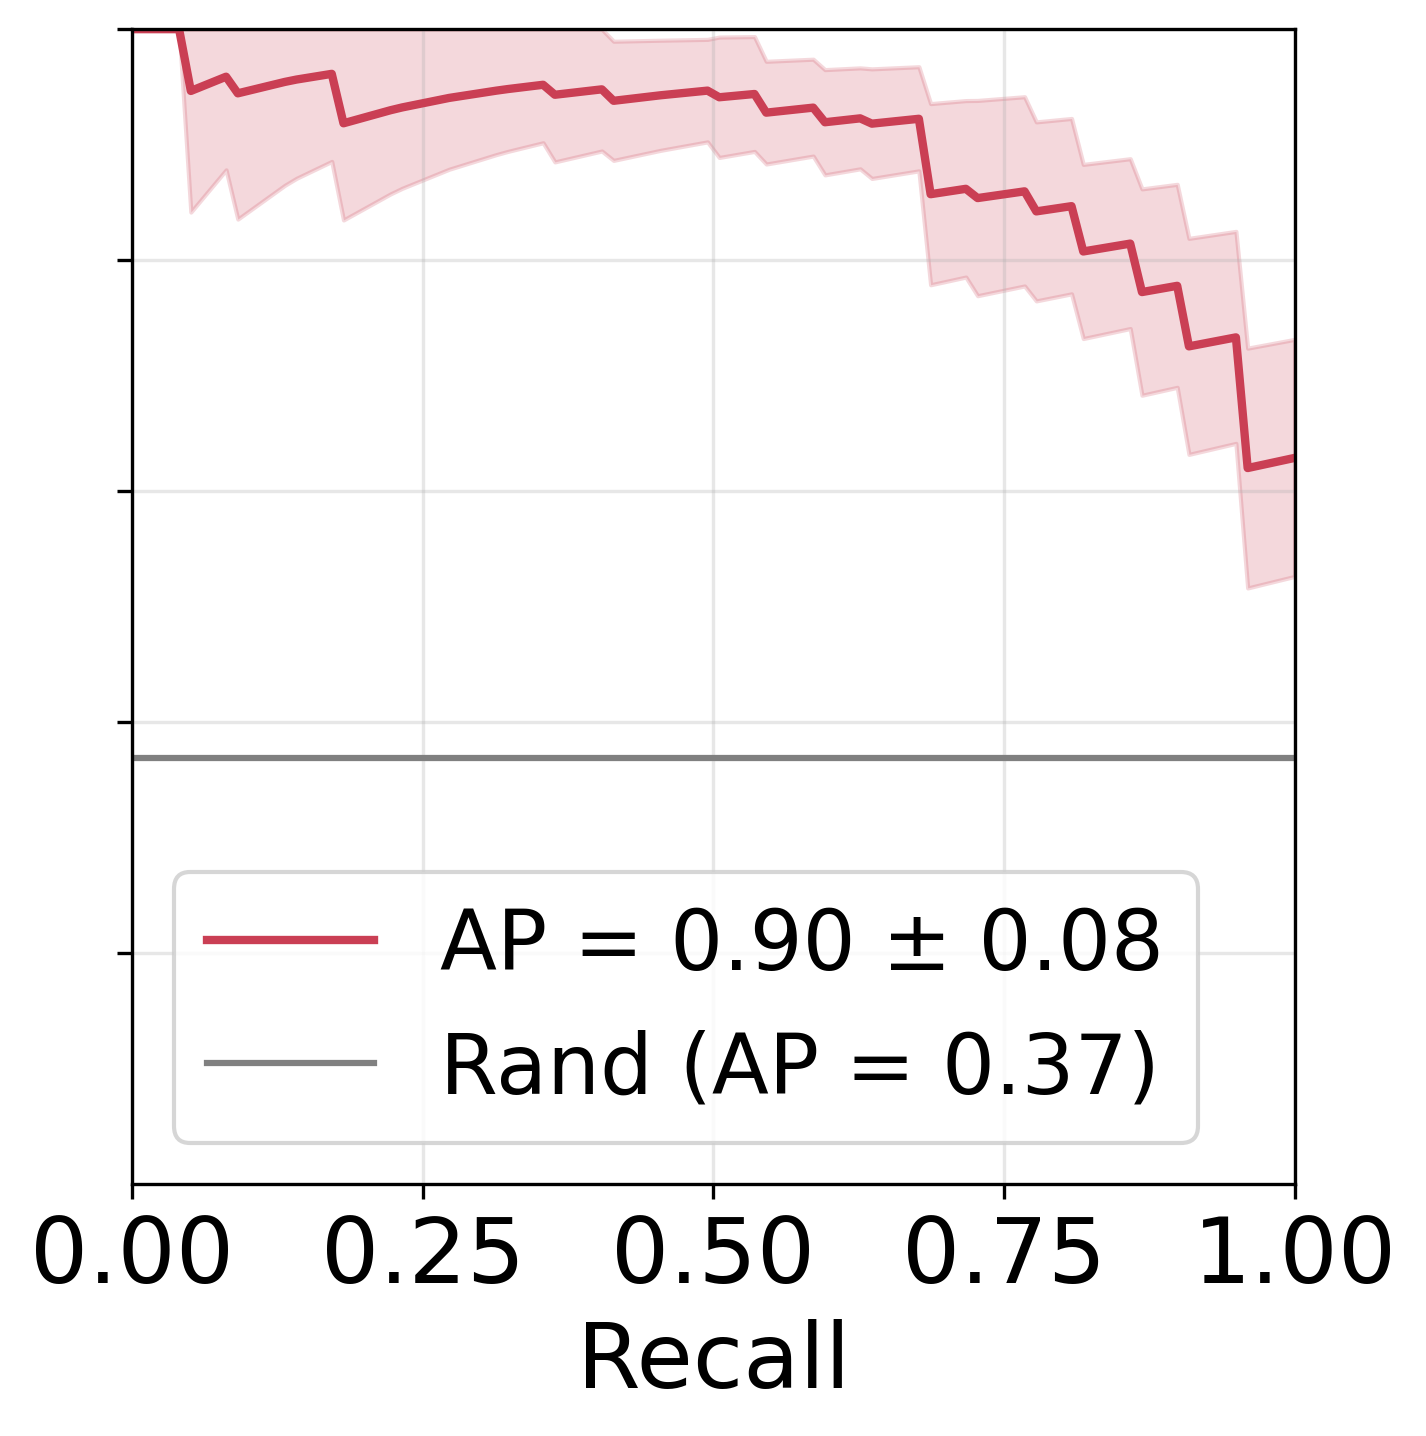

In [ ]:
# ROC
plt.figure(figsize=(fig_size, fig_size), dpi=dpi)
# retinal
reweight = cu_all_probs.copy()
cols = ["Combo"]
reweight["Combo"] = (reweight["Past PEC"] * 0.35 + 0.15 *((reweight["First Preg"]) * (reweight["Age at enrollment"] > 37).astype(int)))
if all_labels:
    plot_avg_roc_from_dicts(reweight, add_col=cols, plot=True, pw=10, color="#CA3F54", rand=True,
                            x_label=True, y_label=True, x_ticks=False, y_ticks=True
                           )
else:
    plot_avg_roc_from_dicts(reweight, add_col=cols, plot=True, pw=10, color="#CA3F54", rand=True,
                            x_label=True, y_label=False, x_ticks=False, y_ticks=False
                           )
    
plt.title("")
plt.savefig(f'/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/temp_plots/cu_{model_type}_{strat_type}_auc.svg') 
plt.show()

# PR
plt.figure(figsize=(fig_size, fig_size), dpi=dpi)
# retinal
reweight = cu_all_probs.copy()
cols = ["Combo"]
reweight["Combo"] = (reweight["Past PEC"] * 0.35 + 0.15 *((reweight["First Preg"]) * (reweight["Age at enrollment"] > 37).astype(int)))
if all_labels:
    plot_avg_pr_from_dicts(reweight, add_col=cols, plot=True, pw=10, color="#CA3F54", rand=True,
                          ) 
else:
    plot_avg_pr_from_dicts(reweight, add_col=cols, plot=True, pw=10, color="#CA3F54", rand=True,
                           x_label=True, y_label=False, x_ticks=True, y_ticks=False
                          )
    
plt.title("")
plt.savefig(f'/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/temp_plots/cu_{model_type}_{strat_type}_pr.svg') 

plt.show()

### nyu

In [32]:
fmf_probs = pd.read_csv("/gpfs/data/shenhavlab/users/ca3261/Visionary_AI/data/fmf_pe_results.csv")
fmf_probs["id"] = [id.lower() for id in fmf_probs["patient_id"]]
fmf_probs["first_preg"] = [int(val == "Nulliparous") for val in fmf_probs["input_obhist"]]
fmf_probs["prev_pec"] = [int(val == "Parous, prev PE") for val in fmf_probs["input_obhist"]]

In [33]:

clinical_feats = pd.read_excel(f'/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/clinical_data/Visionary AI Participant Tracker (2).xlsx',sheet_name='FMF Algorithim ')

clinical_feats = clinical_feats.iloc[0:107]


clinical_feats = clinical_feats.rename(columns={'Record ID':'id'}) 
clinical_feats['id'] = clinical_feats['id'].apply(lambda x: x.lower())

clinical_feats = strings_to_na(clinical_feats, 'Height (m)')
clinical_feats = strings_to_na(clinical_feats, 'Weight (kg)')
clinical_feats = gest_age_to_days(clinical_feats, 'GA at Visit 1 ')
clinical_feats = strings_to_na(clinical_feats, 'Age ')
clinical_feats = datetime_to_day_index(clinical_feats,'EDD')
clinical_feats = add_ethnicity_binaries(clinical_feats, 'Ethnicity')
clinical_feats = proc_smoker(clinical_feats, 'Smoking Status ')
clinical_feats = proc_conception(clinical_feats, 'Conception Method ')
clinical_feats = proc_on_yes(clinical_feats, 'cHTN')
clinical_feats = proc_on_yes(clinical_feats, 'Family Hx diabetes ?')
clinical_feats = proc_db(clinical_feats, 'Diabetes?')
clinical_feats = proc_on_no(clinical_feats, 'Diabetic Drugs?')
clinical_feats = proc_on_no(clinical_feats, 'Systemic lupus ')
clinical_feats = proc_on_no(clinical_feats, 'Anti phospholipid syndrome ')
clinical_feats = proc_on_no(clinical_feats, 'Nulliparity?')
clinical_feats = proc_birth_hx(clinical_feats, 'Pts last birth Dx (PEC/GDM, GHTN, Preterm)')

clinical_feats = gest_age_to_days(clinical_feats, 'GA at delivery ')

clinical_feats = get_ama(clinical_feats, 'Age ')
clinical_feats = get_bmi(clinical_feats, 'Weight (kg)', 'Height (m)')
clinical_feats['obesity'] = clinical_feats['bmi'].apply(lambda x: 1 if x>=30 else 0)

clinical_feats['Current Smoker'] = 0
clinical_feats['Maternal Race_Unknown'] = 0


clinical_feats['Past Hypertension'] = clinical_feats['cHTN'].copy()
clinical_feats['Past Preterm Labor'] = 0


In [34]:
clinical_feats = clinical_feats.drop_duplicates()

In [35]:
nyu_clinical_md = pd.read_csv('/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/clinical_data/nyu_ml_clinical_features_20260501.csv', index_col=0)

In [36]:
nyu_path = "/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/nyu/nyu_rg_delivered_testset/"
nyu_run = "nyu_79_no_repeats_med_pec"

all_probs = []
for i in range(1, 6):
    path = nyu_path + f"{nyu_run}_pw{i}/meta_all_0.5_oof_bls_pw{i}/XGBoost/"
    name = os.listdir(path)[0]
    with open(path + name, "rb") as f:
        data = pickle.load(f)
    all_probs.append(data[1])
all_probs = pd.DataFrame(all_probs)

In [37]:
retinal_probs = pd.DataFrame(all_probs.min(), columns=["retinal"])
retinal_probs["id"] = retinal_probs.index
retinal_probs = retinal_probs.reset_index(drop=True)

retinal_probs = retinal_probs.dropna()

In [ ]:
with open("/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/clinical_data/nyu_evaluation.pkl", "rb") as f:
    eval_data = pickle.load(file=f)

final_exclusions = eval_data["ex"]

ids = list(set(retinal_probs["id"].values) - set(final_exclusions)) # to exclude

In [39]:
retinal_probs = retinal_probs[retinal_probs['id'].isin(ids)]

In [40]:
# ids
nyu_cases = pd.read_pickle('/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/clinical_data/nyu_cases_051126.pkl')

In [41]:
retinal_probs['label'] = retinal_probs['id'].apply(lambda x: 1 if x in nyu_cases else 0)

In [42]:
retinal_probs_clin = retinal_probs.merge(clinical_feats, on='id')

In [43]:
retinal_probs_clin['label'] = retinal_probs_clin['id'].apply(lambda x: 1 if x in nyu_cases else 0)

In [44]:
model_type = 'stable'

In [45]:
if run_obesity:
    retinal_probs_subset = retinal_probs_clin[retinal_probs_clin['bmi']>=30]
if run_no_obesity:
    retinal_probs_subset = retinal_probs_clin[retinal_probs_clin['bmi']<30]
if run_chtn:
    retinal_probs_subset = retinal_probs_clin[retinal_probs_clin['cHTN']==1]
if run_no_chtn:
    retinal_probs_subset = retinal_probs_clin[retinal_probs_clin['cHTN']==0]

/gpfs/data/shenhavlab/users/Daniel/.conda/envs/env1/lib/python3.7/site-packages/ipykernel_launcher.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  This is separate from the ipykernel package so we can avoid doing imports until


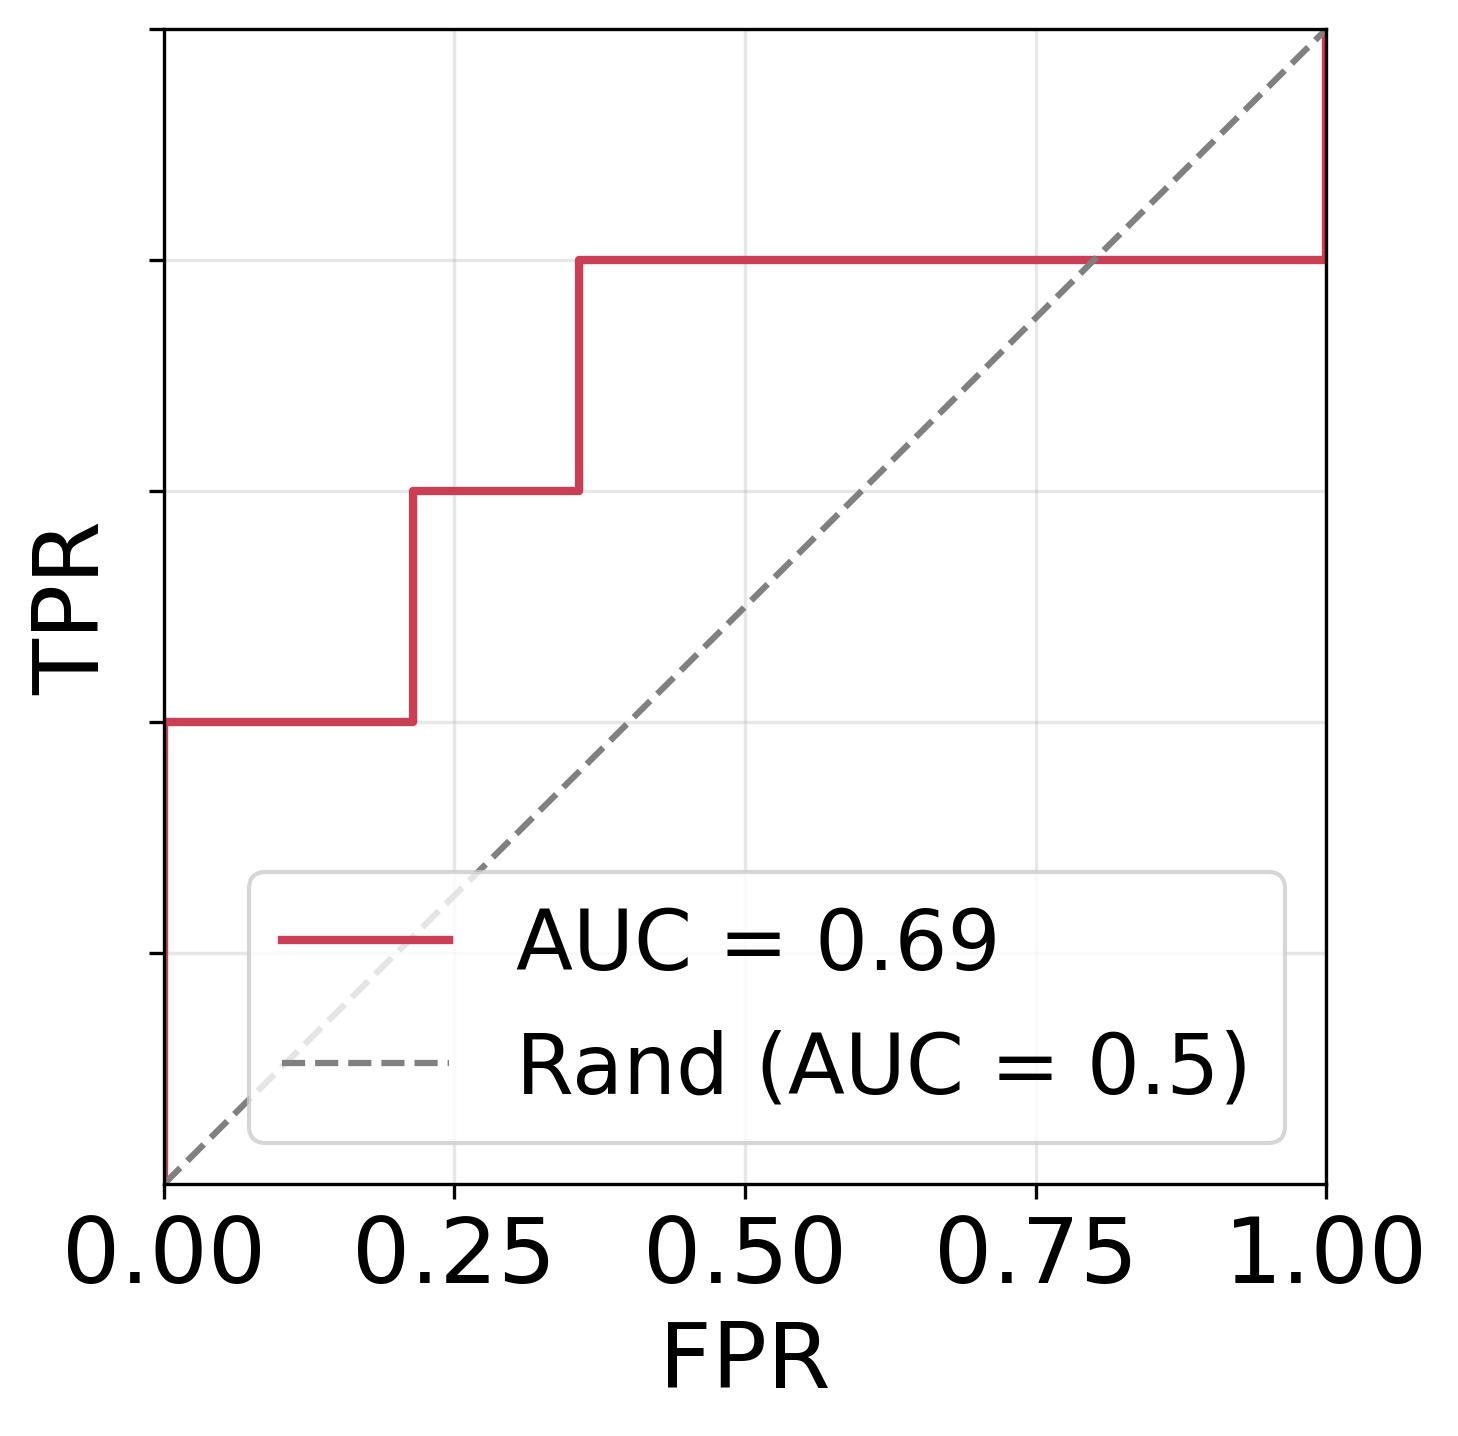

In [46]:
plt.figure(figsize=(fig_size, fig_size), dpi=dpi)
# retinal
retinal_probs_subset["combo"] = (retinal_probs_subset["Past Preeclampsia"] * 0.35 + 0.15 *((retinal_probs_subset["Nulliparity?"]) * (retinal_probs_subset["Age "] > 37).astype(int)))
retinal_probs_subset_t = retinal_probs_subset[["label","retinal","combo"]]
if all_labels:
    get_test_roc(retinal_probs_subset_t.dropna()["label"], retinal_probs_subset_t.dropna()["retinal"] + (retinal_probs_subset_t.dropna()["combo"]),
                 color="#CA3F54",rand=True,
                 x_label=True, y_label=True, x_ticks=True, y_ticks=True
                );
else:
    get_test_roc(retinal_probs_subset_t.dropna()["label"], retinal_probs_subset_t.dropna()["retinal"] + (retinal_probs_subset_t.dropna()["combo"]),
                 color="#CA3F54",rand=True,
                 x_label=True, y_label=True, x_ticks=True, y_ticks=False
                );

plt.savefig(f'/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/temp_plots/nyu_{model_type}_{strat_type}_auc.svg') 
plt.show()

/gpfs/data/shenhavlab/users/Daniel/.conda/envs/env1/lib/python3.7/site-packages/ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  


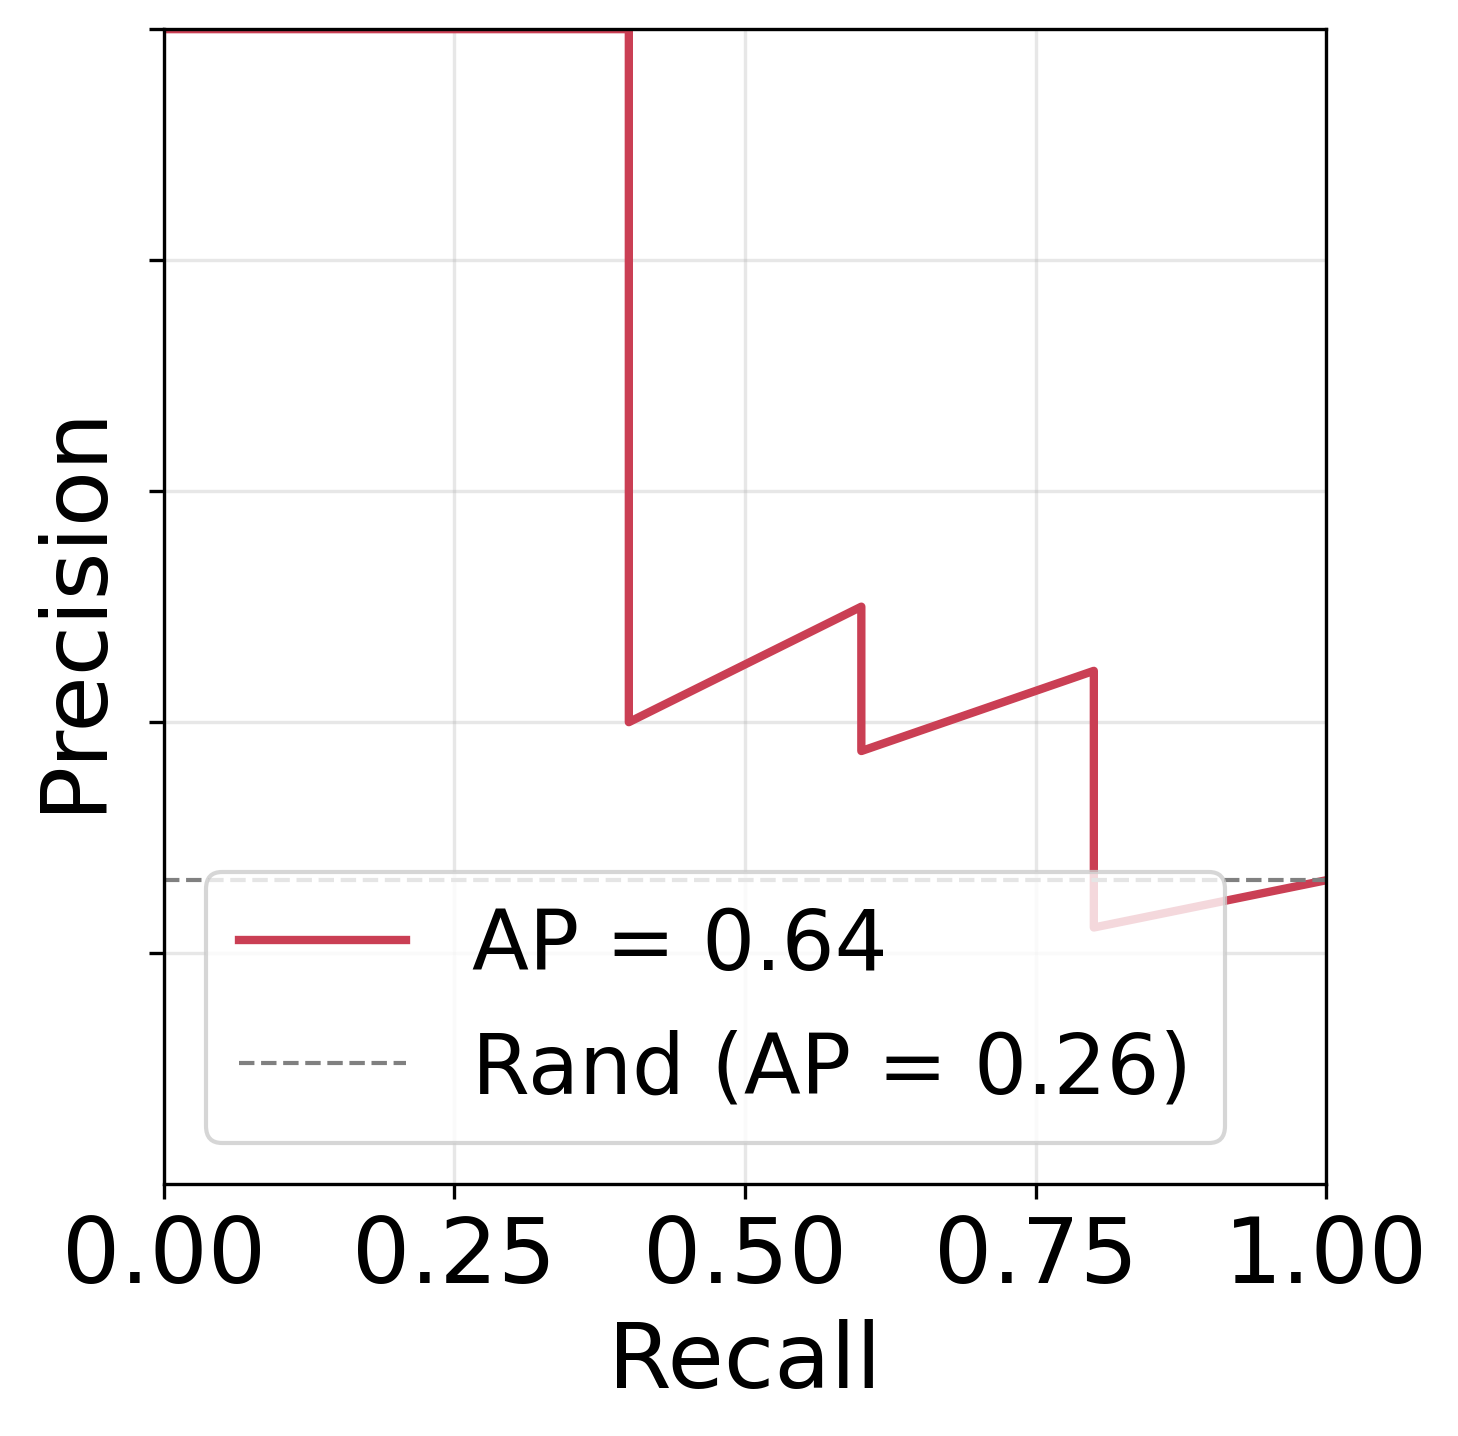

In [47]:
plt.figure(figsize=(fig_size, fig_size), dpi=dpi)
retinal_probs_subset["combo"] = (retinal_probs_subset["Past Preeclampsia"] * 0.35 + 0.15 *((retinal_probs_subset["Nulliparity?"]) * (retinal_probs_subset["Age "] > 37).astype(int)))
retinal_probs_subset_t = retinal_probs_subset[["label","retinal","combo"]]

if all_labels:
    get_test_pr(retinal_probs_subset_t.dropna()["label"], retinal_probs_subset_t.dropna()["retinal"] + (retinal_probs_subset_t.dropna()["combo"]),
                color="#CA3F54", rand=True,
                x_label=True, y_label=True, x_ticks=True, y_ticks=False
               );
else:
    get_test_pr(retinal_probs_subset_t.dropna()["label"], retinal_probs_subset_t.dropna()["retinal"] + (retinal_probs_subset_t.dropna()["combo"]),
                color="#CA3F54", rand=True,
                x_label=True, y_label=True, x_ticks=True, y_ticks=False
               );

plt.savefig(f'/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/temp_plots/nyu_{model_type}_{strat_type}_pr.svg')
plt.show()